In [1]:
import pandas as pd
import matplotlib.pyplot as plt
df=pd.read_excel("Lead_british-startups_companies.xlsx")

Searching for duplicate companies by `Name`, then dropping duplicates keeping the first 
occurrence. I manually checked the duplicate rows beforehand and confirmed dropping the 
first occurrence doesn't lose any meaningful information.

In [2]:
df[df.duplicated(subset="Name", keep=False)] 
df=df.drop_duplicates(subset="Name", keep="first")

Found a few rows with identical `Description` text but different `Name` and `Direct link` 
(e.g. "FLUX AI" vs "FLUX.1 AI", "Vectorize" vs "Vectorize io"). Checking the parent company 
website linked inside each eu-startups page confirmed these are the same real company listed 
twice under slightly different names on the source site. Since the names differ, I can't 
safely decide which row to keep programmatically, so I left both rows in the dataset rather 
than risk dropping the wrong one.

In [3]:
df[df.duplicated(subset="Description")]
description_mask=(df["Description"].notna()) &  df.duplicated(subset="Description", keep=False)
df.loc[description_mask, ["Name", "Foundation year", "Description", "Direct link"]]

,Name,Foundation year,Description,Direct link
539,FLUX AI,2024,Experience the future of AI-powered image crea...,https://www.eu-startups.com/directory/flux-ai/
596,FLUX.1 AI,2024,Experience the future of AI-powered image crea...,https://www.eu-startups.com/directory/flux1-ai/
647,Vectorize,2023,"Fast, Accurate, Production-Ready AI Turn your ...",https://www.eu-startups.com/directory/vectorize/
983,Vectorize io,2014,"Fast, Accurate, Production-Ready AI Turn your ...",https://www.eu-startups.com/directory/vectoriz...


Checking how many unique cities are in the column beforeì cleaning

In [4]:
df["Based in"].nunique()

205

Standardizing all the cities 

In [5]:
df["Based in"]=df["Based in"].str.title()

Searching all the cities in the column "Based in" with city and country, splitting them and assigning
to the column only the right city and then uniforming the spaces after the split

In [6]:
print(df.loc[df["Based in"].str.contains(","), "Based in"])
df["Based in"]=df["Based in"].str.split(",").str[0]
df["Based in"]=df["Based in"].str.strip()

174                               London , Gb
220                               London , Gb
262                            Essex, Romford
273       Birmingham, England, United Kingdom
280                           Oxfordshire, Uk
287                   Gloucestershire, Stroud
297                     Worthing, West Sussex
305                                London, Uk
350                    Co Londonderry, London
371                                London, Uk
418                                 London,Uk
450                             Craigavon, Uk
453                    London, United Kingdom
555                    London, United Kingdom
646                    Greater London, London
717                 Leicestershire, Coalville
743                    London, United Kingdom
745                    Greater London, London
784                                London, Uk
849                                St, Albans
1005                          Sligo, Ash Lane
1016                   London, Uni

Replacing the misspelled city names

In [7]:
df["Based in"]=df["Based in"].replace({"St Albans": "St. Albans", "St. albans": "St. Albans", "St": "St. Albans", "Greater lonodn": "London", "Greater London": "London", "Scottland": "Scotland"})
df["Based in"]=df["Based in"].str.replace("uk", "")

Final check on the cities list. 
205 before the cleaning and 184 after

In [8]:
df["Based in"].nunique()

184

Creating a mask of cities that will not be included in the charts and 
a new flag column that indicates exactly whether the company is based in a city or a town.
Then replacing "True" and "False" with "Yes" or "No"

In [9]:
cities=["England", "United Kingdom", "UK", "Scotland", "Wales", "Northern Ireland", "GB", "Great Britain", "Britain"]
city_mask=df["Based in"].isin(cities)
df["Only country, not city"]=city_mask
df["Only country, not city"]=df["Only country, not city"].replace({True: "Yes", False: "No"}) 

Standardizing all the descriptions

In [10]:
df["Description"]=df["Description"].str.strip() 

Checking for the remainging coloumns, in this case the remaining coloumns are ok

In [11]:
df["Foundation year"].unique()

array([2025, 2020, 2026, 2021, 2009, 2024, 2022, 2012, 2023, 2019, 2018,
       2015, 2007, 2004, 2008, 2017, 2011, 2016, 2013, 2010, 2014, 2006])

In [12]:
df["Funding"].unique()

<StringArray>
[        'No funding announced yet',                 'Between €1-€100K',
              'Between €100K-€500K',        'Between €500K-€ 1 million',
 'Between €1 million-€ 2.5 million',   'Between €2.5 million-5 million',
   'Between €5 million-€10 million',  'Between €10 million-€25 million',
                'Above €25 million',                                nan]
Length: 10, dtype: str

Creating a mask that will be our flag to not include in the charts the country name

In [13]:
flag_city_mask=df["Only country, not city"]=="No"

Visualizing the top 10 cities with the most companies, excluding rows flagged as 
country/region-only rather than an actual city

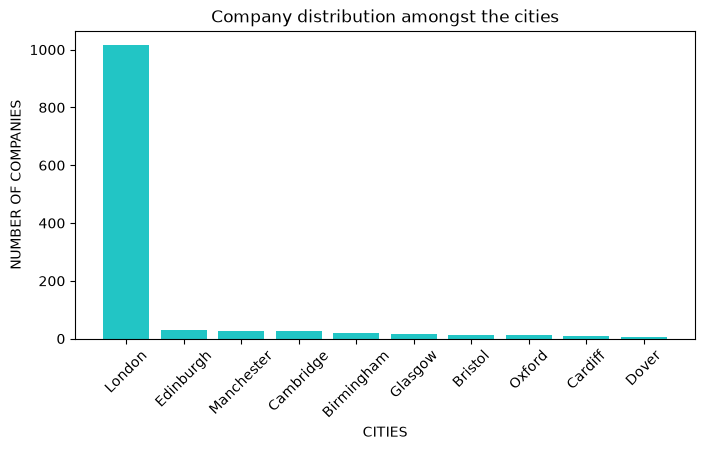

In [14]:
coutn_city=df.loc[flag_city_mask, "Based in"].value_counts().head(10)
plt.figure(figsize=(8,4))
plt.bar(coutn_city.index, coutn_city.values, color="#22c5c5")
plt.xticks(rotation=45)
plt.title("Company distribution amongst the cities")
plt.xlabel("CITIES")
plt.ylabel("NUMBER OF COMPANIES")
plt.savefig("images/top_cities.png", dpi=150, bbox_inches="tight")
plt.show()

Visualizing the distribution of company foundation years as both a bar chart and a line 
chart, side by side, to compare the yearly count and the overall trend

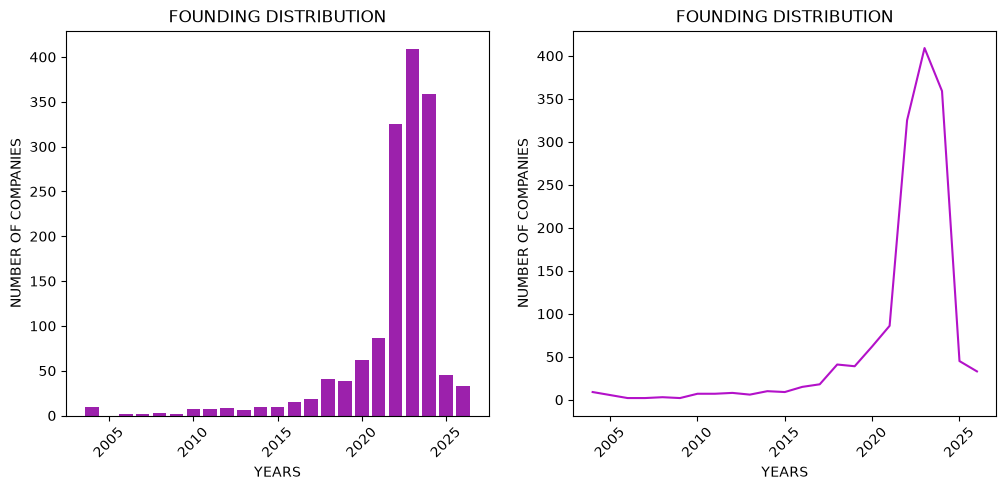

In [15]:
fund_count=df["Foundation year"].value_counts().sort_index()
fig, axes=plt.subplots(1, 2, figsize=(12, 5))
axes[0].bar(fund_count.index, fund_count.values, color="#9c21ac")
axes[0].set_title("FOUNDING DISTRIBUTION")
axes[0].set_xlabel("YEARS")
axes[0].set_ylabel("NUMBER OF COMPANIES")
axes[0].tick_params(axis="x", rotation=45)

axes[1].plot(fund_count.index, fund_count.values, color="#b311c9")
axes[1].set_title("FOUNDING DISTRIBUTION")
axes[1].set_xlabel("YEARS")
axes[1].set_ylabel("NUMBER OF COMPANIES")
axes[1].tick_params(axis="x", rotation=45)
plt.savefig("images/foundation_years.png", dpi=150, bbox_inches="tight")

Creating a mask to exclude companies without funding, then visualizing the distribution 
of funding ranges among the rest

In [16]:
fund_mask=df["Funding"]!="No funding announced yet"

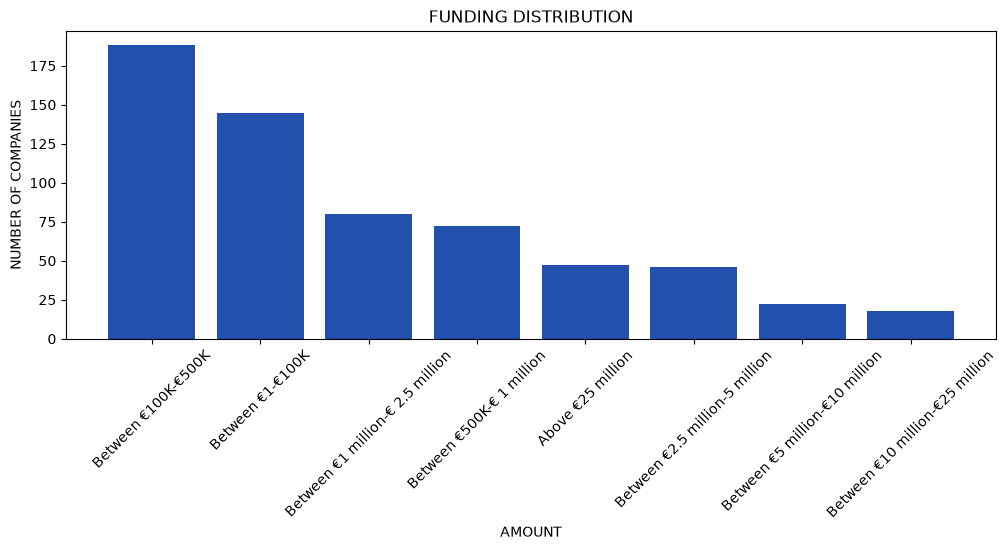

In [17]:
fund_count=df.loc[fund_mask, "Funding"].sort_values().value_counts()
plt.figure(figsize=(12,4))
plt.bar(fund_count.index, fund_count.values, color="#2151ac")
plt.xticks(rotation=45)
plt.title("FUNDING DISTRIBUTION")
plt.xlabel("AMOUNT")
plt.ylabel("NUMBER OF COMPANIES")
plt.savefig("images/funding_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

Saving the cleaned file to excel

In [18]:
df.to_excel("Lead_cleaned.xlsx", index=False)

In [19]:
sample_data=df.head(25)
sample_data.to_excel("samples_data.xlsx", index=False)